In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "/Users/arnarfreyrerlingsson/Desktop/Polymarket_bitcoin_5min/db/polymarket.duckdb"

In [2]:
def query_to_df(query, limit=1000):
    if limit:
        limit = f"\n LIMIT {limit}"
    else:
        limit = ""

    con = duckdb.connect(DB_PATH,read_only=True)
    try:
        query = str(query) + limit
        df = con.execute(query).df()
        return df
    finally:
        con.close()

In [3]:
query = """
SELECT COUNT(*) AS N_ROWS,MIN(OPEN_TIME) AS DATE_START, MAX(OPEN_TIME) AS DATE_END, MAX(OPEN_TIME)-MIN(OPEN_TIME) AS NUM_DAYS
FROM bitcoin_prices
"""
query_to_df(query)

,N_ROWS,DATE_START,DATE_END,NUM_DAYS
0,10281600,2026-06-01 00:00:00+00:00,2026-09-27 23:59:59+00:00,118 days 23:59:59


In [8]:
query = """
WITH BASE AS (
    SELECT OPEN_TIME AS THE_TIME,
           OPEN AS PRICE,
           VOLUME,
           QUOTE_VOLUME,
           COUNT,
           TAKER_BUY_VOLUME,
           TAKER_BUY_QUOTE_VOLUME,
           IGNORE
    FROM bitcoin_prices
)
SELECT
    M.MARKET_ID,
    M.EVENT_SLUG,
    M.EVENT_START_TIME,
    M.END_DATE,
    B.THE_TIME,
    B.PRICE,
    B.VOLUME,
    B.QUOTE_VOLUME,
    B.COUNT,
    B.TAKER_BUY_VOLUME,
    B.TAKER_BUY_QUOTE_VOLUME



FROM BASE B
LEFT JOIN DIM_MARKET M
       ON B.THE_TIME >= M.EVENT_START_TIME
      AND B.THE_TIME <  M.END_DATE

"""
query_to_df(query)

,MARKET_ID,EVENT_SLUG,EVENT_START_TIME,END_DATE,THE_TIME,PRICE,VOLUME,QUOTE_VOLUME,COUNT,TAKER_BUY_VOLUME,TAKER_BUY_QUOTE_VOLUME
0,3239257,btc-updown-5m-1785580800,2026-08-01 10:40:00+00:00,2026-08-01 10:45:00+00:00,2026-08-01 10:42:39+00:00,63056.00,0.02186,1378.404151,4,0.02095,1321.023200
1,3239257,btc-updown-5m-1785580800,2026-08-01 10:40:00+00:00,2026-08-01 10:45:00+00:00,2026-08-01 10:42:38+00:00,63055.99,0.00835,526.517517,1,0.00000,0.000000
2,3239257,btc-updown-5m-1785580800,2026-08-01 10:40:00+00:00,2026-08-01 10:45:00+00:00,2026-08-01 10:42:37+00:00,63055.99,0.00013,8.197279,1,0.00000,0.000000
3,3239257,btc-updown-5m-1785580800,2026-08-01 10:40:00+00:00,2026-08-01 10:45:00+00:00,2026-08-01 10:42:36+00:00,63055.99,0.00411,259.160119,1,0.00000,0.000000
4,3239257,btc-updown-5m-1785580800,2026-08-01 10:40:00+00:00,2026-08-01 10:45:00+00:00,2026-08-01 10:42:35+00:00,63055.99,0.00123,77.558874,2,0.00062,39.094720
...,...,...,...,...,...,...,...,...,...,...,...
995,3238991,btc-updown-5m-1785579900,2026-08-01 10:25:00+00:00,2026-08-01 10:30:00+00:00,2026-08-01 10:26:04+00:00,63042.01,0.00011,6.934621,1,0.00011,6.934621
996,3238991,btc-updown-5m-1785579900,2026-08-01 10:25:00+00:00,2026-08-01 10:30:00+00:00,2026-08-01 10:26:03+00:00,63042.01,0.00000,0.000000,0,0.00000,0.000000
997,3238991,btc-updown-5m-1785579900,2026-08-01 10:25:00+00:00,2026-08-01 10:30:00+00:00,2026-08-01 10:26:02+00:00,63042.01,0.00000,0.000000,0,0.00000,0.000000
998,3238991,btc-updown-5m-1785579900,2026-08-01 10:25:00+00:00,2026-08-01 10:30:00+00:00,2026-08-01 10:26:01+00:00,63042.01,0.02951,1860.369624,5,0.02038,1284.796164


In [9]:
query = """
SELECT OPEN_TIME AS THE_TIME,OPEN AS PRICE,VOLUME,QUOTE_VOLUME,COUNT,TAKER_BUY_VOLUME,TAKER_BUY_QUOTE_VOLUME,IGNORE
FROM bitcoin_prices
    ORDER BY OPEN_TIME ASC
"""
df = query_to_df(query,1000000)


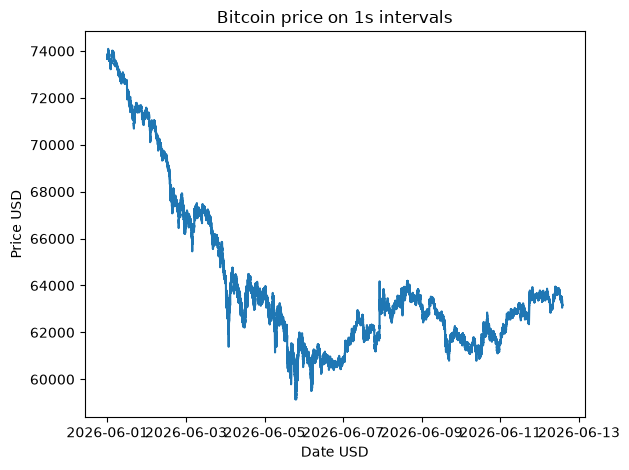

In [10]:
plt.plot(df['THE_TIME'],df['PRICE'])
plt.ylabel("Price USD")
plt.xlabel("Date USD")
plt.title("Bitcoin price on 1s intervals")
plt.tight_layout()
plt.show()